In [11]:
import numpy as np #importando biblioteca para estatistica e chamando de np


In [12]:
lista_idades = [26, 30, 32, 22, 26, 35, 40, 20, 43, 31, 23]

In [13]:
np.sum(lista_idades)

np.int64(328)

In [14]:
len(lista_idades)

11

In [15]:
np.sum(lista_idades)/len(lista_idades)

np.float64(29.818181818181817)

In [16]:
media = np.mean(lista_idades)
print('Media Aritmetica:', media)

Media Aritmetica: 29.818181818181817


In [17]:
lista_idades.sort()
lista_idades

[20, 22, 23, 26, 26, 30, 31, 32, 35, 40, 43]

In [18]:
mediana = np.median(lista_idades)
mediana

np.float64(30.0)

TABELA


In [19]:
from google.colab import drive

In [10]:
drive.mount ('/content/drive/')

Mounted at /content/drive/


In [20]:
import pandas as pd

In [21]:
dados = pd.read_excel('/content/drive/MyDrive/PROGRAMARIA/modulo-3/planilha_modulo3.xlsx')

In [22]:
dados['IDADE'].mean()

np.float64(31.169168453657374)

In [23]:
dados['IDADE'].median()

30.0

In [24]:
dados['IDADE'].mode() #moda

,IDADE
0,27.0


In [25]:
dados['IDADE'].std()#desvio padrão

6.902802832143141

In [26]:
dados['IDADE'].min()

18.0

In [27]:
dados['IDADE'].max()

54.0

In [28]:
dados[dados['GENERO']== 'Feminino']['IDADE'].mean()

np.float64(31.318051575931232)

In [29]:
dados[dados['GENERO']== 'Feminino']['SALARIO'].mean()

np.float64(8673.22460496614)

In [30]:
dados[dados['GENERO']== 'Masculino']['SALARIO'].mean()


np.float64(11724.552688172043)

In [31]:
dados[dados['GENERO']== 'Masculino']['IDADE'].mean()

np.float64(31.147876077930373)

In [32]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Data columns (total 28 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   Unnamed: 0                                                                                                                 4271 non-null   int64  
 1   ID                                                                                                                         4271 non-null   object 
 2   IDADE                                                                                                                      4197 non-null   float64
 3   FAIXA IDADE                                                                                                                4271 

ARUMMANDO GENERO

In [33]:
dados.groupby('GENERO', dropna=False)['ID'].nunique()

,ID
GENERO,
Feminino,1055
Masculino,3194
Prefiro não informar,12
NaN,9


In [34]:
dados['GENERO'] = dados['GENERO'].fillna("Prefiro não informar") #tirando nulos preenchendo com fill na

In [35]:
dados.groupby('GENERO', dropna=False)['ID'].nunique()

,ID
GENERO,
Feminino,1055
Masculino,3194
Prefiro não informar,21


TRABALHANDO COLUNA IDADE

In [36]:
dados['IDADE'].isnull().value_counts()#contando quantos nulos =74

,count
IDADE,
False,4197
True,74


Nessa tabela temos faixa de idadei, para não responder errado e perder os nulos, fará a substituição

Primeiro os 17-21


In [37]:
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()#faixa de idade das pessoas q não preencheram idade

,count
FAIXA IDADE,
55+,68
17-21,6


In [38]:
media_17_21 = dados[dados['FAIXA IDADE']=='17-21']['IDADE'].mean()

In [39]:
dados.loc[(dados['FAIXA IDADE']=='17-21') & (dados['IDADE'].isnull()), 'IDADE']#LOCALIZANDO FAIXA DE 17 A 21 ONDE ESTA NULO

,IDADE
1925,NaN
2393,NaN
3367,NaN
4086,NaN
4177,NaN
4269,NaN


In [40]:
dados.loc[(dados['FAIXA IDADE']=='17-21') & (dados['IDADE'].isnull()), 'IDADE'] = media_17_21 #SUBSTITUINDO PELA FAIXA

In [41]:
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()#

,count
FAIXA IDADE,
55+,68


AGORA DOS RESTANTES 55+

In [42]:
dados[dados['FAIXA IDADE']=='55+']['IDADE']

,IDADE
9,NaN
66,NaN
96,NaN
121,NaN
156,NaN
...,...
4001,NaN
4043,NaN
4048,NaN
4061,NaN


In [43]:
dados[dados['FAIXA IDADE']=='55+']['NIVEL']

,NIVEL
9,Pleno
66,Júnior
96,Pleno
121,Pleno
156,Júnior
...,...
4001,NaN
4043,NaN
4048,NaN
4061,NaN


In [44]:
media_geral = dados['IDADE'].mean()
media_geral

np.float64(31.153517220250375)

In [45]:
dados.loc[(dados['FAIXA IDADE']=='55+') & (dados['IDADE'].isnull()), 'IDADE'] = media_geral

In [46]:
dados['IDADE'].isnull().value_counts()

,count
IDADE,
False,4271


TRATANDO SALARIO

In [47]:
dados[dados['SALARIO'].isnull()]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
12,12,zwr9hqcpg513kaopenzwr9hibaqmldto,31.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,28,ztgepgj82o9oix0nztgepq2trcay6gpv,24.0,22-24,Feminino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,34,zsa9i6njd3e594mw0tvlk4zsa9iw86i9,24.0,22-24,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,39,zr4b2vm7dapp3linwqwn7zr4b2vmagqx,32.0,30-34,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,63,zm7o5yquakof0j6zm7vh3o0letznhdvh,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4242,4242,09oxwp6lsdwhw09ox1uobuxa8cq2pzma,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4252,4252,064pe9b1htw7mflhif064pe95dotv6yf,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4260,4260,03atvow8404tatt2iixjds03atvownkz,36.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
dados[dados['SALARIO'].isnull()]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,


PESSOAS Q DEIXARAM SALARIO NULOS TAMBEM NÃO FALARAM A FAIXA, USAR MEDIANA

In [49]:
mediana_salario = dados['SALARIO'].median()

In [50]:
dados.loc[dados['SALARIO'].isnull(), 'SALARIO'] = mediana_salario

In [51]:
dados[dados['SALARIO'].isnull()]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,


###4.2 Valores discrepantes


In [52]:
lista_idades = [26, 30, 32, 22, 26, 35, 40, 20, 43, 31, 23]

In [53]:
np.mean(lista_idades)

np.float64(29.818181818181817)

In [54]:
lista_idades = [26, 30, 32, 22, 26, 35, 400, 20, 43, 31, 23]

In [55]:
media = np.mean(lista_idades)
media

np.float64(62.54545454545455)

Regra do desvio padra: mais proximo de zero, mais adequado

In [56]:
desvio = np.std(lista_idades)
desvio

np.float64(106.89532997398872)

In [57]:
media + 3*desvio #limite mais alto

np.float64(383.2314444674207)

In [58]:
media - 3*desvio #limite mais baixo

np.float64(-258.1405353765116)

Método mais adequado para analisar outliers QUARTIS. Feito a partir de 3 números, metade de cima e baixo e a do meio da mediana

###IMPORTANDO A BIBLIOTECA

In [59]:
import matplotlib.pyplot as plt


{'whiskers': [<matplotlib.lines.Line2D at 0x79450e5697f0>,
 'caps': [<matplotlib.lines.Line2D at 0x79450e569be0>,
 'boxes': [<matplotlib.lines.Line2D at 0x79450e5bf230>],
 'medians': [<matplotlib.lines.Line2D at 0x79450e5692b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x79450e56bbf0>],
 'means': []}

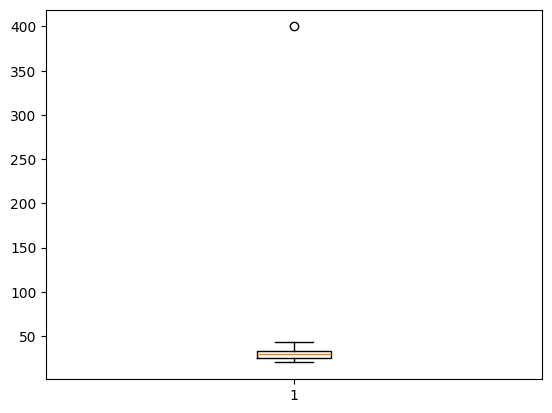

In [60]:
plt.boxplot(lista_idades)


Q1 ESTA NO PRIMEIRO TRAÇO E Q3 NO ULTIMO

{'whiskers': [<matplotlib.lines.Line2D at 0x79450e10f170>,
 'caps': [<matplotlib.lines.Line2D at 0x79450e10f6b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x79450e10c2f0>],
 'medians': [<matplotlib.lines.Line2D at 0x79450e10fcb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x79450e10ffb0>],
 'means': []}

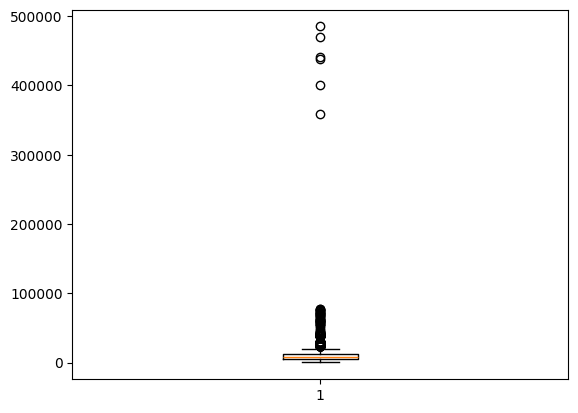

In [61]:
plt.boxplot(dados['SALARIO']) #OUTLIERS EM SALARIO

In [62]:
q1 = dados['SALARIO'].quantile(0.25)
q1

np.float64(4751.5)

In [63]:
q3 = dados['SALARIO'].quantile(0.75)
q3

np.float64(11794.5)

In [64]:
iqr = q3 - q1
iqr

np.float64(7043.0)

In [65]:
lim_superior = q3 +(1.5*iqr)
lim_superior

np.float64(22359.0)

In [66]:
lim_inferior = q1 - (1.5*iqr)
lim_inferior

np.float64(-5813.0)

In [67]:
dados['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,
de R$ 8.001/mês a R$ 12.000/mês,752
de R$ 4.001/mês a R$ 6.000/mês,584
de R$ 6.001/mês a R$ 8.000/mês,527
de R$ 12.001/mês a R$ 16.000/mês,437
de R$ 3.001/mês a R$ 4.000/mês,303
de R$ 2.001/mês a R$ 3.000/mês,285
de R$ 16.001/mês a R$ 20.000/mês,229
de R$ 1.001/mês a R$ 2.000/mês,216
de R$ 20.001/mês a R$ 25.000/mês,134


In [68]:
media_salario = dados['SALARIO'].mean()
media_salario

np.float64(10517.53348162023)

In [69]:
desvio_salario = dados['SALARIO'].std()
desvio_salario


18096.210989118474

In [70]:
limite_superior = media_salario + (3*desvio_salario)
limite_superior

np.float64(64806.16644897565)

In [71]:
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,
Acima de R$ 40.001/mês,19
de R$ 30.001/mês a R$ 40.000/mês,3


In [72]:
media_30_40 = dados[(dados['FAIXA SALARIAL']== 'de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO'] < limite_superior)]['SALARIO'].mean()

In [73]:
dados.loc[(dados['FAIXA SALARIAL']== 'de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO'] > limite_superior), 'SALARIO'] =  media_30_40

In [74]:
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,
Acima de R$ 40.001/mês,19


In [75]:
media_40 = dados[(dados['FAIXA SALARIAL']== 'Acima de R$ 40.001/mês') & (dados['SALARIO'] < limite_superior)]['SALARIO'].mean()

In [76]:
dados.loc[(dados['FAIXA SALARIAL']== 'Acima de R$ 40.001/mês') & (dados['SALARIO'] > limite_superior), 'SALARIO'] =  media_40

In [77]:
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,


{'whiskers': [<matplotlib.lines.Line2D at 0x79450e1831d0>,
 'caps': [<matplotlib.lines.Line2D at 0x79450e1837d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x79450e182f00>],
 'medians': [<matplotlib.lines.Line2D at 0x79450e183c80>],
 'fliers': [<matplotlib.lines.Line2D at 0x79450e183fb0>],
 'means': []}

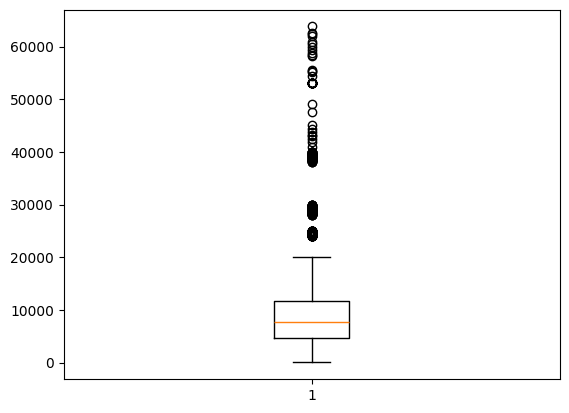

In [78]:
plt.boxplot(dados['SALARIO'])

###4.3 Itervalo de confiança e distribuição amostral.

Amostra e intervalo de confiança

In [79]:
salarios = dados['SALARIO']

In [80]:
salarios

,SALARIO
0,11194.0
1,4695.0
2,14202.0
3,15463.0
4,7733.0
...,...
4266,4329.0
4267,3758.0
4268,19607.0
4269,989.0


In [81]:
media_amostral = np.mean(salarios)
media_amostral

np.float64(9904.390109813306)

In [82]:
desvio_amostral = np.std(salarios)
desvio_amostral

8306.104872579343

In [83]:
nivel_confiança = 0.95

In [84]:
tamanho_amostra = len(salarios)
tamanho_amostra

4271

DIVISÃO DAS AMOSTRAS EM GRUPOS IMPORTANDO OUTRA BIBLIOTECA

In [85]:
from scipy import stats

In [86]:
erro_padrao = stats.sem(salarios)
erro_padrao

np.float64(127.11109872023638)

In [87]:
intervalo_confiança = stats.t.interval(nivel_confiança, tamanho_amostra-1, loc=media_amostral, scale=erro_padrao)
intervalo_confiança

(np.float64(9655.186295869078), np.float64(10153.593923757535))

###4.5Featuring engeneering-


Selecionar criando e transformando dados brutos, preparaçã.
Na maioria das vezes: criação de novas variaveis a partir de combinções de ja existentes

In [88]:
def preencher_nivel(gestor, nivel):
  if gestor == 1:
    return "Pessoa Gestora"
  else:
    return nivel

In [89]:
dados.apply(lambda x: preencher_nivel(x['GESTOR?'], x['NIVEL']), axis=1)

,0
0,Júnior
1,Pessoa Gestora
2,Pleno
3,Sênior
4,Pleno
...,...
4266,Pleno
4267,Pleno
4268,Pessoa Gestora
4269,Júnior


In [90]:
dados['NOVO NIVEL'] = dados.apply(lambda x: preencher_nivel(x['GESTOR?'], x['NIVEL']), axis=1)

In [91]:
dados['NOVO NIVEL'].value_counts()

,count
NOVO NIVEL,
Pleno,1060
Júnior,1023
Sênior,898
Pessoa Gestora,713


dados categoricos em indicadores

In [92]:
dados['NIVEL']

,NIVEL
0,Júnior
1,NaN
2,Pleno
3,Sênior
4,Pleno
...,...
4266,Pleno
4267,Pleno
4268,NaN
4269,Júnior


In [93]:
pd.get_dummies(dados, columns=['NIVEL'])

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,CARGO COMO GESTOR,CARGO ATUAL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO,NOVO NIVEL,NIVEL_Júnior,NIVEL_Pleno,NIVEL_Sênior
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.000000,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,DBA/Administrador de Banco de Dados,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0,Júnior,True,False,False
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.000000,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Supervisor/Coordenador,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0,Pessoa Gestora,False,False,False
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.000000,50-54,Masculino,Branca,Não,NaN,NaN,True,...,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0,Pleno,False,True,False
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.000000,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,Cientista de Dados/Data Scientist,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,15463.0,Sênior,False,False,True
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.000000,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0,Pleno,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4266,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.000000,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,Analista de Dados/Data Analyst,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos,4329.0,Pleno,False,True,False
4267,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.000000,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3758.0,Pleno,False,True,False
4268,4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.000000,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Gerente/Head,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,19607.0,Pessoa Gestora,False,False,False
4269,4269,00xu7yujd7s57emj00xu7y0c3njix3de,20.205479,17-21,Masculino,Branca,Não,NaN,NaN,True,...,NaN,Outra Opção,Menos de R$ 1.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,989.0,Júnior,True,False,False


In [94]:
dados = pd.get_dummies(dados, columns=['NIVEL'])

In [95]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior'],
      dtype='object')

In [96]:
def determinar_geracao(idade):
  if 39<idade<=58:
    return "Geração X"
  elif 29< idade <=39:
    return "Millenial"
  elif 13< idade<=29:
    return "Geração Z"
  else:
    return "Outra Geração"


In [97]:
dados['GERACAO'] = dados['IDADE'].apply(determinar_geracao)

In [98]:
dados['GERACAO'].value_counts()

,count
GERACAO,
Geração Z,1999
Millenial,1761
Geração X,511


Merge juntas as tabelas, a partir de um dado em comum para relacionar

In [99]:
dados2 = pd.read_excel('/content/drive/MyDrive/PROGRAMARIA/mod-4/Planilha_Aula_parte2.xlsx')

In [100]:
dados.merge(dados2, on='ID', how='left')  #mergiar os dados da esquerda

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,Qual o principal motivo da sua insatisfação com a empresa atual?,Você participou de entrevistas de emprego nos últimos 6 meses?,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.000000,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,Não participei de entrevistas de emprego/proce...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.000000,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Falta de oportunidade de crescimento no empreg...,"Sim, fiz entrevistas mas não fui aprovado",Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.000000,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,1
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.000000,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,"Sim, fui aprovado e mudei de emprego","Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.000000,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4268,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.000000,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,"Sim, fui aprovado e mudei de emprego",Não estou buscando e não pretendo mudar de emp...,"Remuneração/Salário, Benefícios, Flexibilidade...",Modelo 100% remoto,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,Análise de Dados,SQL
4269,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.000000,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,Não participei de entrevistas de emprego/proce...,Não estou buscando e não pretendo mudar de emp...,"Ambient

In [101]:
dados = dados.merge(dados2, on='ID', how='left')

In [102]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satis

In [103]:
dados['Você pretende mudar de emprego nos próximos 6 meses?'].value_counts()

,count
Você pretende mudar de emprego nos próximos 6 meses?,
"Não estou buscando, mas me considero aberto a outras oportunidades",1354
Estou em busca de oportunidades dentro ou fora do Brasil,1011
Não estou buscando e não pretendo mudar de emprego nos próximos 6 meses,978
"Estou em busca de oportunidades, mas apenas fora do Brasil",353


In [104]:
dados['EM_BUSCA']= dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains('em busca', case=False)

In [105]:
dados['EM_BUSCA'].value_counts()

,count
EM_BUSCA,
False,2332
True,1364


In [106]:
dados['ABERTO_OPORTUNIDADES']= dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains('aberto', case=False)

In [107]:
dados['ABERTO_OPORTUNIDADES'].value_counts()

,count
ABERTO_OPORTUNIDADES,
False,2342
True,1354


Tetando criar nova coluna de etnias

###4.6-Correlação: descreve a relação entre variaveis, a partir de estatisticas

positiva: 2variaveis aumentam juntas, negativa: 1 aumenta e outra diminui

In [108]:
correlacao_continua = dados['IDADE'].corr(dados['SALARIO'])
correlacao_continua

np.float64(0.2902441968622099)

Apesar de positiva não é tão forte para ser realmente significativa, no caso dessas tabelas e desses dados


In [109]:
from scipy.stats import chi2_contingency #depois da fun def abaixo

In [110]:
def cramer_coeficiente(coluna1, coluna2):
  tabela_cruzada = pd.crosstab(coluna1, coluna2)



In [111]:
 tabela_cruzada = pd.crosstab(dados['COR/RACA/ETNIA'], dados['NIVEL DE ENSINO'])
 tabela_cruzada

NIVEL DE ENSINO,Doutorado ou Phd,Estudante de Graduação,Graduação/Bacharelado,Mestrado,Não tenho graduação formal,Prefiro não informar,Pós-graduação
COR/RACA/ETNIA,,,,,,,
Amarela,7,15,50,14,2,0,40
Branca,127,365,999,355,65,8,827
Indígena,0,2,4,2,0,0,3
Outra,0,0,6,3,1,0,7
Parda,50,178,333,113,33,3,344
Prefiro não informar,1,2,14,1,0,1,7
Preta,6,51,104,33,9,0,88


In [112]:
np.array(tabela_cruzada)

array([[  7,  15,  50,  14,   2,   0,  40],
       [127, 365, 999, 355,  65,   8, 827],
       [  0,   2,   4,   2,   0,   0,   3],
       [  0,   0,   6,   3,   1,   0,   7],
       [ 50, 178, 333, 113,  33,   3, 344],
       [  1,   2,  14,   1,   0,   1,   7],
       [  6,  51, 104,  33,   9,   0,  88]])

In [113]:
def cramer_coeficiente(coluna1, coluna2):#depois
  tabela_cruzada = np.array(pd.crosstab(coluna1, coluna2))
  chi2 = chi2_contingency(tabela_cruzada)[0]
  soma = np.sum(tabela_cruzada)
  mini = min(tabela_cruzada.shape)-1
  cramer = np.sqrt(chi2/(soma*mini))
  return cramer

In [114]:
cramer_coeficiente(dados['COR/RACA/ETNIA'], dados['NIVEL DE ENSINO'])

np.float64(0.04499106580480143)

cramer valor do q^2 normalizado entre 0 e 1, mais proximo de zero menor relação e mais prox de 1 maior relação

ANALISE E CONTEXTO= partindo da analise da tabelas partimos do ponto que não há diferença entre brancos e não brancosem ensino, mas a tabela possui em seus dados maior parte apenas pessoas que ja possuem ensino como resposta

In [115]:
 tabela_cruzada_genero = pd.crosstab(dados['GENERO'], dados['NIVEL DE ENSINO'])
 tabela_cruzada_genero

NIVEL DE ENSINO,Doutorado ou Phd,Estudante de Graduação,Graduação/Bacharelado,Mestrado,Não tenho graduação formal,Prefiro não informar,Pós-graduação
GENERO,,,,,,,
Feminino,57,104,365,133,24,3,372
Masculino,134,506,1138,386,86,8,936
Prefiro não informar,0,3,7,2,0,1,8


In [116]:
np.array(tabela_cruzada_genero)

array([[  57,  104,  365,  133,   24,    3,  372],
       [ 134,  506, 1138,  386,   86,    8,  936],
       [   0,    3,    7,    2,    0,    1,    8]])

In [117]:
def cramer_coeficiente(coluna1, coluna2):
  tabela_cruzada_genero = pd.crosstab(coluna1, coluna2)

In [118]:
def cramer_coeficiente(coluna1, coluna2):#depois
  tabela_cruzada_genero = np.array(pd.crosstab(coluna1, coluna2))
  chi2 = chi2_contingency(tabela_cruzada_genero)[0]
  soma = np.sum(tabela_cruzada_genero)
  mini = min(tabela_cruzada_genero.shape)-1
  cramer = np.sqrt(chi2/(soma*mini))
  return cramer

In [119]:
cramer_coeficiente(dados['GENERO'], dados['NIVEL DE ENSINO'])

np.float64(0.076119232802818)

Temos coeficiente de q^2 perto de zero= significa que a disparidade entre genero e nivel de ensino nesta tabela existe

In [120]:
dados.to_csv('/content/drive/MyDrive/PROGRAMARIA/analise_dados1.csv', index=False)

ja tem salvo o analise _dados, devido ao sumiço do outro notebook

###5.6CONECTANDO SQL COM PANDAS

In [121]:
import sqlite3


In [122]:
conexao = sqlite3.connect('/content/drive/MyDrive/PROGRAMARIA/status_brasil')


In [123]:
query = "SELECT * FROM Municipios_Brasileiros WHERE Cidade='Itaquaquecetuba';"


In [124]:
query


"SELECT * FROM Municipios_Brasileiros WHERE Cidade='Itaquaquecetuba';"

In [125]:
pd.read_sql(query, con=conexao)


,Cidade,Estado,Regiao,municipio_ID
0,Itaquaquecetuba,SP,Sudeste,5043


In [126]:
pd.read_sql(query, con=conexao)

,Cidade,Estado,Regiao,municipio_ID
0,Itaquaquecetuba,SP,Sudeste,5043


In [127]:
dados = pd.read_csv('/content/drive/MyDrive/PROGRAMARIA/analise_dados1.csv')

In [128]:
lista_estados = list(dados['UF ONDE MORA'].unique())

In [129]:
query = '''SELECT Municipios_Brasileiros.Estado, AVG(Municipios_Status.renda) FROM Municipios_Brasileiros
        INNER JOIN Municipios_Status ON Municipios_Brasileiros.municipio_ID = Municipios_Status.municipio_ID
        WHERE Municipios_Brasileiros.Estado IN ({})
        GROUP BY Municipios_Brasileiros.Estado;'''.format(', '.join(['?' for _ in lista_estados]))

In [130]:
estados_renda = pd.read_sql(query, con=conexao, params=lista_estados)

In [131]:
print(query)

SELECT Municipios_Brasileiros.Estado, AVG(Municipios_Status.renda) FROM Municipios_Brasileiros
        INNER JOIN Municipios_Status ON Municipios_Brasileiros.municipio_ID = Municipios_Status.municipio_ID
        WHERE Municipios_Brasileiros.Estado IN (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        GROUP BY Municipios_Brasileiros.Estado;


In [132]:
dados.rename(columns={'UF ONDE MORA':'Estado'}, inplace=True)

In [133]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'Estado', 'REGIAO ONDE MORA',
       'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO',
       'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [134]:
dados = dados.merge(estados_renda, on='Estado', how='left')

In [135]:
coreelacao_renda_salario = dados['SALARIO'].corr(dados['AVG(Municipios_Status.renda)'])
coreelacao_renda_salario

np.float64(0.12083384881429463)

###6.3 VISUALIZAÇÃO DE DADOS

J

In [136]:
dados.head()

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES,AVG(Municipios_Status.renda)
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,False,False,0.863000
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,True,False,0.572357
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,"Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,1,False,True,0.863000
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,"Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,0,False,True,0.652008
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,"Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,False,True,0.572357


GRAFICOS

In [137]:
genero_counts = dados['GENERO'].value_counts()

In [138]:
import matplotlib.pyplot as plt


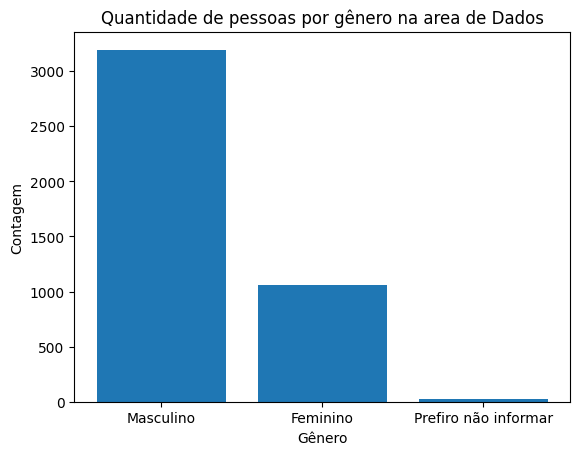

In [139]:
plt.figure()
plt.bar(height = genero_counts.values, x = genero_counts.index)
plt.title('Quantidade de pessoas por gênero na area de Dados')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.show()

In [140]:
import seaborn as sns

/tmp/ipykernel_2334/3423927789.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




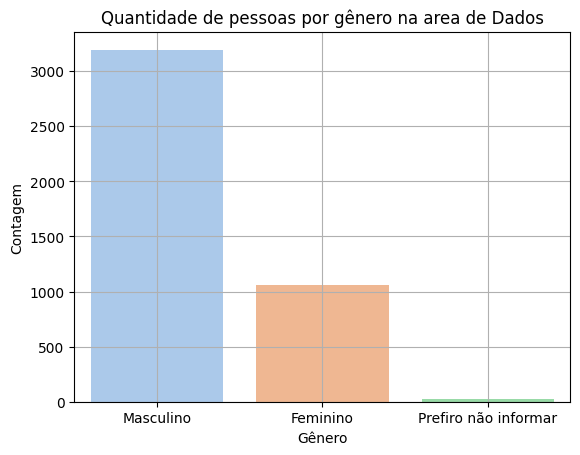

In [141]:
plt.figure()
sns.countplot(data = dados, x = 'GENERO', palette = 'pastel')
plt.title('Quantidade de pessoas por gênero na area de Dados')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.grid(True)
plt.show()

Verificando se a média de salarios varia conforme a idade

In [142]:
salario_por_idade = dados.groupby('IDADE')['SALARIO'].mean()

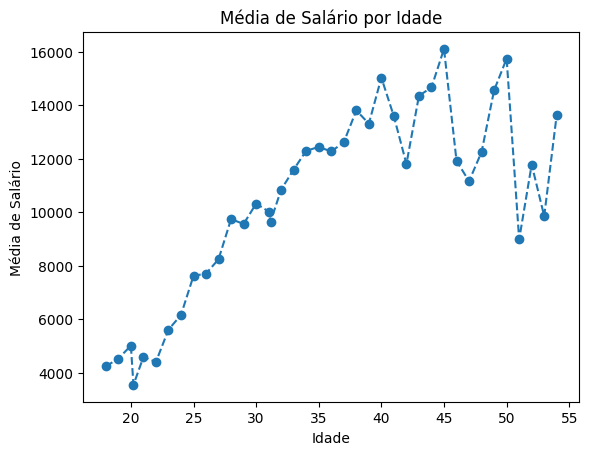

In [143]:
plt.figure()
plt.plot(salario_por_idade.index, salario_por_idade.values, marker='o', linestyle='--')
plt.xlabel('Idade')
plt.ylabel('Média de Salário')
plt.title('Média de Salário por Idade')
plt.show()

In [144]:
import plotly.express as px

In [145]:
fig = px.line(salario_por_idade.reset_index(), x='IDADE', y='SALARIO', title='Média de Salário por Idade', markers=True)
fig.show()

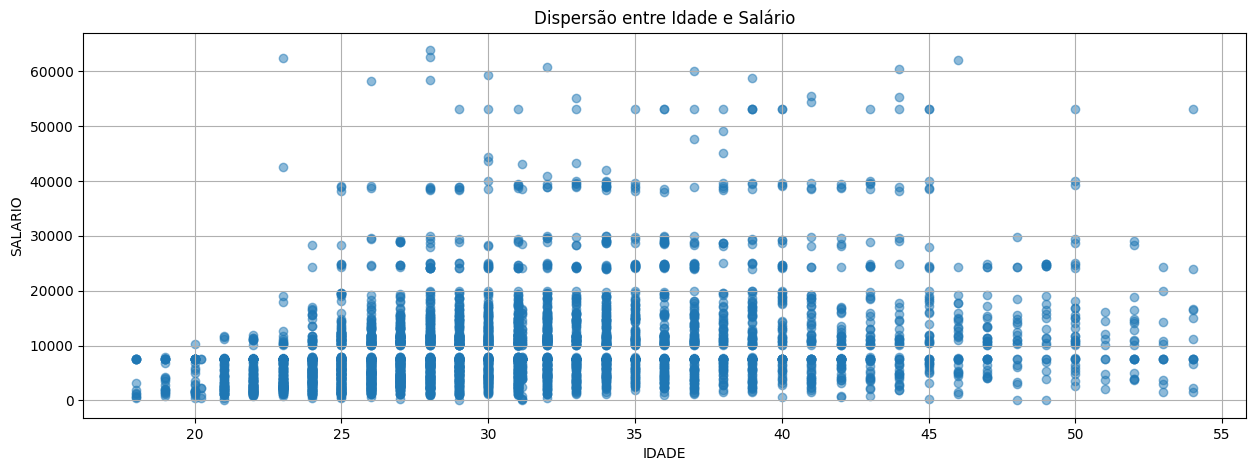

In [146]:
plt.figure(figsize=(15,5))
plt.scatter(dados['IDADE'], dados['SALARIO'], alpha=0.5)
plt.xlabel('IDADE')
plt.ylabel('SALARIO')
plt.title('Dispersão entre Idade e Salário')
plt.grid(True)
plt.show()

In [147]:
fig = px.scatter(dados, x='IDADE', y='SALARIO', title='Dispersão entre Idade e Salário', trendline='ols')
fig.show()